# Model Explainability & Interpretability

As ML models grow more complex, understanding **why** a model makes a prediction becomes as important as accuracy. Explainability enables trust, debugging, compliance (GDPR), and bias detection.

## Taxonomy

| Dimension | Options |
|-----------|----------|
| Scope | **Local** (single prediction) vs **Global** (overall model behavior) |
| Dependency | **Model-agnostic** (works on any model) vs **Model-specific** (tree SHAP, attention) |
| Type | Feature importance, example-based, concept-based |

---

## 1. SHAP (SHapley Additive exPlanations)

Based on **Shapley values** from cooperative game theory. The Shapley value for feature $i$ is:

$$\phi_i(f) = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]$$

where $F$ = all features, $S$ = coalition of features, $f(S)$ = prediction using only features in $S$.

### SHAP Properties
1. **Efficiency**: $\sum_i \phi_i = f(x) - E[f(X)]$ (predictions sum to baseline + contributions)
2. **Symmetry**: Equal features get equal SHAP values
3. **Dummy**: Irrelevant features get SHAP value = 0
4. **Additivity**: SHAP values from ensembles sum correctly

### SHAP Variants
- **TreeSHAP**: $O(TLD^2)$ exact computation for trees (fast!)
- **KernelSHAP**: Model-agnostic, uses weighted linear regression in feature space
- **DeepSHAP**: Uses DeepLIFT backpropagation for neural networks
- **LinearSHAP**: Exact for linear models

Model accuracy: 0.9561


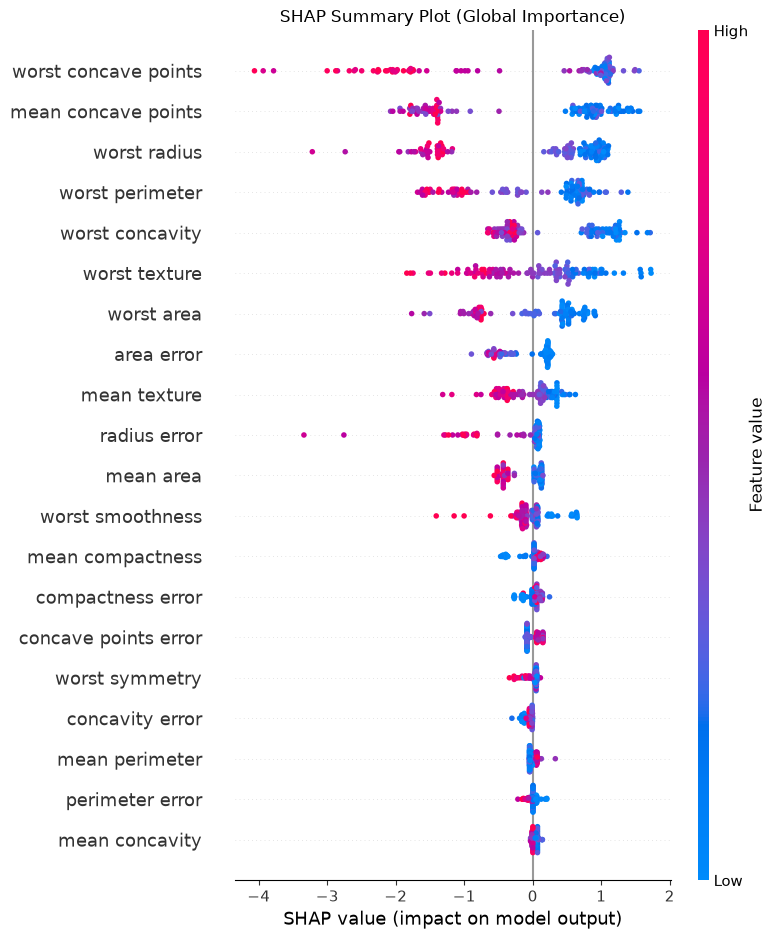


Explaining prediction for sample 0:
Predicted: 1, Actual: 1
SHAP values (top 5 features):
  mean concave points                : +1.1397
  worst concave points               : +1.1187
  worst perimeter                    : +0.8195
  worst radius                       : +0.5818
  worst area                         : +0.5664


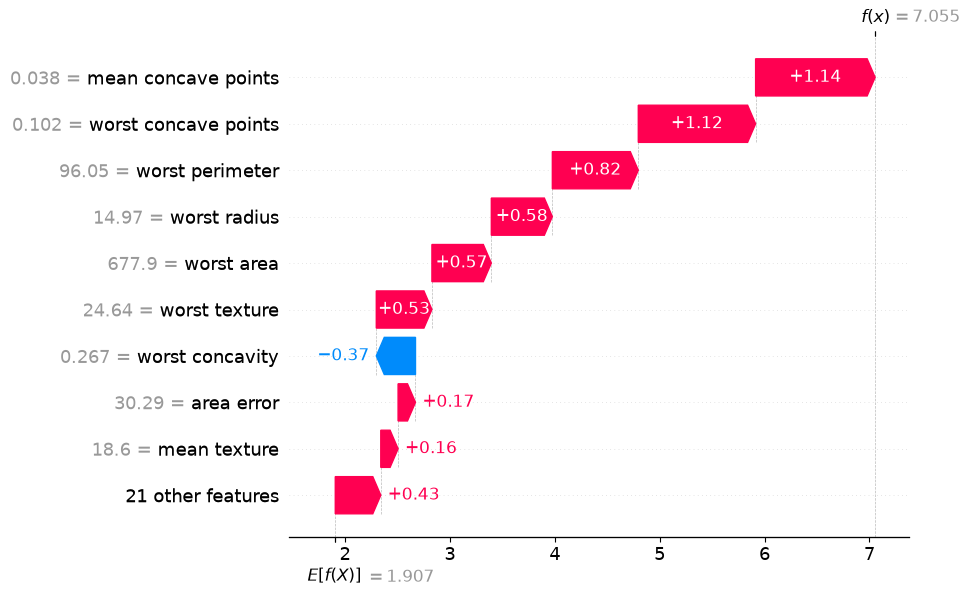

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import warnings; warnings.filterwarnings('ignore')

# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = GradientBoostingClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(f"Model accuracy: {model.score(X_test, y_test):.4f}")

# SHAP
try:
    import shap
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # Summary plot (global importance)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title("SHAP Summary Plot (Global Importance)")
    plt.tight_layout()
    plt.show()
    
    # Force plot (single prediction)
    idx = 0
    print(f"\nExplaining prediction for sample {idx}:")
    print(f"Predicted: {model.predict(X_test.iloc[[idx]])[0]}, Actual: {y_test[idx]}")
    print(f"SHAP values (top 5 features):")
    sv = dict(zip(data.feature_names, shap_values[idx]))
    for feat, val in sorted(sv.items(), key=lambda x: abs(x[1]), reverse=True)[:5]:
        print(f"  {feat:35s}: {val:+.4f}")
        
    # Waterfall plot
    shap.waterfall_plot(shap.Explanation(values=np.array(shap_values[idx]),
                                          base_values=np.ravel(explainer.expected_value)[0],
                                          data=X_test.iloc[idx].values,
                                          feature_names=list(data.feature_names)), show=True)
except ImportError:
    print("Install SHAP: pip install shap")

---

## 2. LIME (Local Interpretable Model-agnostic Explanations)

Fits a **simple interpretable model** locally around a prediction:

$$\xi(x) = \arg\min_{g \in G} \mathcal{L}(f, g, \pi_x) + \Omega(g)$$

where:
- $f$: complex black-box model
- $g$: simple explanation model (e.g., linear model)
- $\pi_x$: proximity measure around instance $x$
- $\mathcal{L}$: fidelity of $g$ approximating $f$ in neighborhood
- $\Omega(g)$: complexity of $g$

**Process**:
1. Generate perturbed samples around $x$ by sampling $z \sim \mathcal{N}(x, \sigma^2 I)$
2. Weight by proximity: $\pi_x(z) = \exp(-D(x,z)^2/\sigma^2)$
3. Get predictions from $f$ on perturbed samples
4. Fit weighted linear model on perturbed samples

## 3. Permutation Feature Importance

Measures how much model performance drops when a feature is randomly shuffled:
$$\text{PFI}_j = \text{score}(X) - \text{score}(X_{\text{shuffle}_j})$$

Model-agnostic. Can be computed on train or test set (test preferred).

## 4. Partial Dependence Plots (PDP)

Shows marginal effect of one or two features:
$$\hat{f}_{x_S}(x_S) = \mathbb{E}_{x_C}[f(x_S, x_C)] = \int f(x_S, x_C) p(x_C) dx_C$$

Approximated by averaging predictions over all data points with feature $j$ set to a fixed value.

## 5. Individual Conditional Expectation (ICE)

Like PDP but shows individual lines per sample instead of the average. Reveals heterogeneous effects:
$$\hat{f}^{(i)}_{x_S}(x_S) = f(x_S, x_C^{(i)})$$

Top 10 Permutation Importances:
               feature  importance_mean  importance_std
          worst radius         0.012281        0.011234
          mean texture         0.004386        0.004386
  worst concave points         0.004386        0.016293
            area error         0.003509        0.004297
      worst smoothness         0.000877        0.002632
        mean perimeter         0.000000        0.000000
      mean compactness         0.000000        0.000000
        mean concavity         0.000000        0.000000
mean fractal dimension         0.000000        0.000000
         mean symmetry         0.000000        0.000000

Top 10 MDI (Mean Decrease Impurity) Importances:
             feature  importance
 mean concave points    0.450528
worst concave points    0.240103
        worst radius    0.075636
     worst perimeter    0.051375
       worst texture    0.039886
          worst area    0.038245
        mean texture    0.027806
     worst concavity    0.018725
     

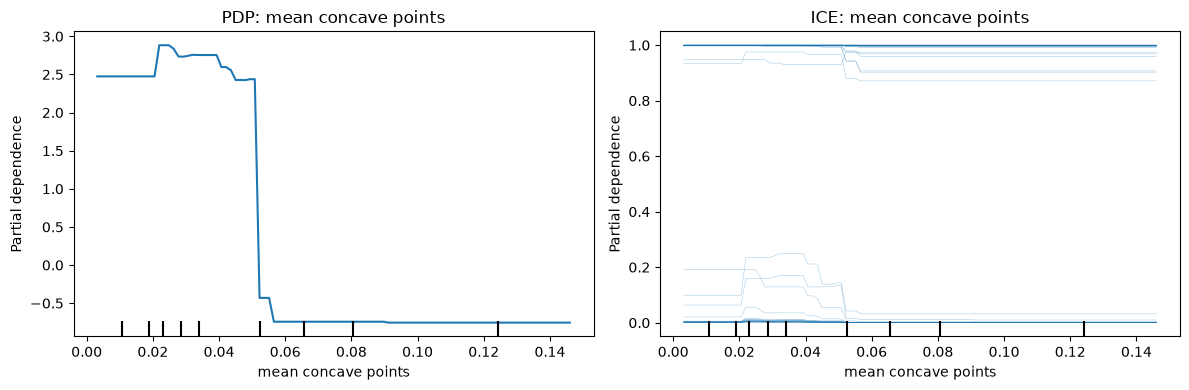


LIME Explanation (top 10 features):
  13.05 < worst radius <= 14.97: +0.1361
  0.23 < worst concavity <= 0.39: -0.1220
  84.25 < worst perimeter <= 97.67: +0.0991
  0.10 < worst concave points <= 0.16: +0.0810
  0.03 < mean concave points <= 0.07: -0.0723
  21.05 < worst texture <= 25.22: +0.0682
  516.45 < worst area <= 686.60: +0.0590
  0.32 < radius error <= 0.47: +0.0465
  16.17 < mean texture <= 18.68: +0.0350
  0.08 < worst fractal dimension <= 0.09: +0.0320


In [2]:
# Permutation Feature Importance
perm_imp = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({'feature': data.feature_names,
                         'importance_mean': perm_imp.importances_mean,
                         'importance_std': perm_imp.importances_std
                        }).sort_values('importance_mean', ascending=False)
print("Top 10 Permutation Importances:")
print(perm_df.head(10).to_string(index=False))

# Built-in Feature Importance (MDI)
mdi_df = pd.DataFrame({'feature': data.feature_names,
                        'importance': model.feature_importances_
                       }).sort_values('importance', ascending=False)
print("\nTop 10 MDI (Mean Decrease Impurity) Importances:")
print(mdi_df.head(10).to_string(index=False))

# PDP + ICE Plots
top_feature = mdi_df.iloc[0]['feature']
top_idx = list(data.feature_names).index(top_feature)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(model, X_test, [top_idx], ax=axes[0],
                                         kind='average')
axes[0].set_title(f'PDP: {top_feature}')
PartialDependenceDisplay.from_estimator(model, X_test, [top_idx], ax=axes[1],
                                         kind='individual', subsample=50)
axes[1].set_title(f'ICE: {top_feature}')
plt.tight_layout(); plt.show()

# LIME
try:
    from lime import lime_tabular
    lime_exp = lime_tabular.LimeTabularExplainer(
        X_train.values, feature_names=data.feature_names,
        class_names=['malignant', 'benign'], mode='classification'
    )
    explanation = lime_exp.explain_instance(X_test.iloc[0].values, model.predict_proba, num_features=10)
    print("\nLIME Explanation (top 10 features):")
    for feat, weight in explanation.as_list():
        print(f"  {feat}: {weight:+.4f}")
except ImportError:
    print("Install LIME: pip install lime")

---

## 6. GRAD-CAM (for CNNs)

Generates heatmaps showing which regions of an image the CNN focused on:

$$\alpha_k^c = \frac{1}{Z}\sum_i\sum_j \frac{\partial y^c}{\partial A^k_{ij}}$$

$$L^c_{\text{Grad-CAM}} = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right)$$

where $A^k$ = activation maps of last conv layer, $y^c$ = class score.

## 7. Integrated Gradients

Attributes prediction to input features using path integrals:

$$\text{IntGrad}_i(x) = (x_i - x'_i) \int_{\alpha=0}^{1} \frac{\partial F(x' + \alpha(x-x'))}{\partial x_i} d\alpha$$

where $x'$ is a baseline (e.g., all zeros). Satisfies completeness axiom: $\sum_i \text{IntGrad}_i = F(x) - F(x')$.

## 8. Model Cards

Structured documentation for ML models (Google's framework):
- Model details, intended use, factors, metrics
- Evaluation data, training data, quantitative analyses
- Ethical considerations, caveats

---

## Additional Learning Resources

### Papers
- **SHAP** (Lundberg & Lee): [https://arxiv.org/abs/1705.07874](https://arxiv.org/abs/1705.07874)
- **LIME**: [https://arxiv.org/abs/1602.04938](https://arxiv.org/abs/1602.04938)
- **GRAD-CAM**: [https://arxiv.org/abs/1610.02391](https://arxiv.org/abs/1610.02391)
- **Integrated Gradients**: [https://arxiv.org/abs/1703.01365](https://arxiv.org/abs/1703.01365)
- **Model Cards**: [https://arxiv.org/abs/1810.03993](https://arxiv.org/abs/1810.03993)

### Libraries
- **SHAP**: [https://shap.readthedocs.io/](https://shap.readthedocs.io/)
- **LIME**: [https://github.com/marcotcr/lime](https://github.com/marcotcr/lime)
- **Captum** (PyTorch): [https://captum.ai/](https://captum.ai/)
- **Alibi**: [https://docs.seldon.io/projects/alibi/](https://docs.seldon.io/projects/alibi/)
- **InterpretML**: [https://interpret.ml/](https://interpret.ml/)

### Books
- **Interpretable Machine Learning** (Molnar, free): [https://christophm.github.io/interpretable-ml-book/](https://christophm.github.io/interpretable-ml-book/)